# CeNN-QML-TSF Benchmark — implementation

This notebook implements IEEE Access experimental.

**Protocol**
- 4 datasets: Energy, AAPL Finance, Mackey-Glass, Jena Climate.
- 6 models: Seasonal Naive, ARIMA/SARIMAX, MLP, LSTM, TransformerEncoder, locally connected CeNN.
- 5 seeds: 42, 43, 44, 45, 46.
- Chronological split: 70% train, 15% validation, 15% test.
- Scaler fitted on train only.
- Metrics: MAE, RMSE, MAPE, sMAPE, R², latency, training time, parameter count.
- Statistical validation: run-level paired tests, point-level error tests, Diebold-Mariano-style comparison, 95% CI, Cohen's d.
- Outputs: CSV results, LaTeX tables, figures, model checkpoints, and a ZIP package.

**Important rule for manuscript use:** do not report results from a dataset marked `is_synthetic_fallback=True`.


## 0. Dataset access

The notebook first tries to use datasets attached to the Kaggle notebook under `/kaggle/input`. It can also optionally use `kagglehub` downloads when Internet is enabled.

Recommended Kaggle datasets to attach manually:
- `robikscube/hourly-energy-consumption` for energy load
- `meetnagadia/apple-stock-price-from-19802021` or another AAPL CSV
- `mnassrib/jena-climate` for Jena Climate

Mackey-Glass is generated deterministically by code and is not treated as a synthetic fallback because it is a standard chaotic benchmark.


In [2]:
# Kaggle usually has most of these packages pre-installed.
# kagglehub/yfinance are optional and only used when Internet is available.
!pip install -q yfinance statsmodels openpyxl scipy scikit-learn tqdm kagglehub


## 1. Imports and configuration

In [3]:
import os, gc, json, math, time, random, zipfile, warnings, platform
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

CONFIG = {
    "seeds": [42, 43, 44, 45, 46],
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "window": 24,
    "horizon": 1,
    "max_points_per_dataset": 6000,

    # Training
    "epochs": 50,
    "patience": 8,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,

    # Baseline/model sizes
    "mlp_hidden": 128,
    "lstm_hidden": 64,
    "transformer_d_model": 64,
    "transformer_nhead": 4,
    "transformer_layers": 2,

    # Local CeNN configuration
    "cenn_cells": 64,
    "cenn_radius": 2,
    "cenn_steps": 6,
    "cenn_dt": 0.15,

    # Optional switches
    "run_arima": True,
    "run_ablation": True,
    "use_kagglehub_downloads": True,
    "allow_synthetic_fallback_for_pipeline_test": True,

    # Optional explicit file paths. Set these if automatic discovery selects the wrong CSV.
    "energy_path": None,
    "jena_path": None,
    "aapl_csv_path": None,

    "out_dir": "/kaggle/working/outputs_revision"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR = Path(CONFIG["out_dir"])
for sub in ["results", "figures", "tables", "models", "logs", "configs"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Environment metadata for the reproducibility package.
ENV_INFO = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
with open(OUT_DIR / "logs" / "environment_info.json", "w") as f:
    json.dump(ENV_INFO, f, indent=2)

with open(OUT_DIR / "configs" / "experiment_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

ENV_INFO


Device: cuda
GPU: Tesla T4


{'python': '3.12.12',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35',
 'torch': '2.10.0+cu128',
 'cuda_available': True,
 'cuda_device': 'Tesla T4',
 'numpy': '2.0.2',
 'pandas': '2.3.3'}

In [4]:
# Optional KaggleHub downloads.
# If Internet is OFF or a slug fails, the notebook will continue and search /kaggle/input.
DATA_ROOTS = [Path("/kaggle/input")]

KAGGLEHUB_SLUGS = {
    "jena_climate": "mnassrib/jena-climate",
    "aapl": "meetnagadia/apple-stock-price-from-19802021",
    "energy": "robikscube/hourly-energy-consumption",
    # Mackey-Glass is generated deterministically below.
}

if CONFIG.get("use_kagglehub_downloads", True):
    try:
        import kagglehub
        for dataset_name, slug in KAGGLEHUB_SLUGS.items():
            try:
                p = Path(kagglehub.dataset_download(slug))
                if p.exists():
                    DATA_ROOTS.append(p)
                    print(f"[kagglehub] {dataset_name}: {p}")
            except Exception as e:
                print(f"[kagglehub skipped] {dataset_name} ({slug}): {repr(e)}")
    except Exception as e:
        print(f"[kagglehub unavailable] {repr(e)}")

# Remove duplicates and persist roots in CONFIG.
seen, unique_roots = set(), []
for p in DATA_ROOTS:
    sp = str(p)
    if sp not in seen and p.exists():
        seen.add(sp)
        unique_roots.append(p)
CONFIG["data_roots"] = [str(p) for p in unique_roots]
with open(OUT_DIR / "configs" / "experiment_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Search roots:")
for r in unique_roots:
    print(" -", r)


[kagglehub] jena_climate: /kaggle/input/datasets/mnassrib/jena-climate
[kagglehub] aapl: /kaggle/input/datasets/meetnagadia/apple-stock-price-from-19802021
[kagglehub] energy: /kaggle/input/datasets/robikscube/hourly-energy-consumption
Search roots:
 - /kaggle/input
 - /kaggle/input/datasets/mnassrib/jena-climate
 - /kaggle/input/datasets/meetnagadia/apple-stock-price-from-19802021
 - /kaggle/input/datasets/robikscube/hourly-energy-consumption


## 2. Reproducibility helpers and metrics

In [5]:
def set_seed(seed):
    """Set random seeds for controlled reproducibility.

    Full bitwise determinism is not guaranteed on every GPU backend, but this
    configuration substantially reduces run-to-run variation.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def safe_smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100.0

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": float(safe_mape(y_true, y_pred)),
        "sMAPE": float(safe_smape(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)) if len(np.unique(y_true)) > 1 else np.nan,
    }

def confidence_interval_mean(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = stats.sem(x)
    tcrit = stats.t.ppf((1 + confidence) / 2.0, df=len(x)-1)
    return (float(mean - tcrit * sem), float(mean + tcrit * sem))

def bootstrap_ci_mean(x, n_boot=2000, confidence=0.95, block_size=None, seed=123):
    """Bootstrap CI for the mean.

    If block_size is provided, uses circular block bootstrap, which is safer
    for autocorrelated time-series residuals than iid resampling.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    means = []
    if block_size is None or block_size <= 1:
        for _ in range(n_boot):
            means.append(np.mean(rng.choice(x, size=n, replace=True)))
    else:
        block_size = int(max(1, min(block_size, n)))
        starts = np.arange(n)
        for _ in range(n_boot):
            sample = []
            while len(sample) < n:
                st = int(rng.choice(starts))
                idx = (st + np.arange(block_size)) % n
                sample.extend(x[idx].tolist())
            means.append(np.mean(sample[:n]))
    alpha = (1 - confidence) / 2
    return (float(np.quantile(means, alpha)), float(np.quantile(means, 1 - alpha)))

def cohens_d_paired(diff):
    diff = np.asarray(diff, dtype=float)
    diff = diff[~np.isnan(diff)]
    sd = np.std(diff, ddof=1)
    if len(diff) < 2 or sd == 0:
        return np.nan
    return float(np.mean(diff) / sd)

def diebold_mariano_test(y_true, y_pred_a, y_pred_b, power=1, h=1):
    """Simple Diebold-Mariano-style test.

    Negative mean loss differential favors model A.
    Uses a small Newey-West style correction up to h-1 lags.
    For h=1, this reduces to a t-test on loss differentials.
    """
    y_true = np.asarray(y_true).reshape(-1)
    e_a = np.asarray(y_true - np.asarray(y_pred_a).reshape(-1))
    e_b = np.asarray(y_true - np.asarray(y_pred_b).reshape(-1))
    if power == 1:
        d = np.abs(e_a) - np.abs(e_b)
    else:
        d = e_a**2 - e_b**2
    d = d[~np.isnan(d)]
    n = len(d)
    if n < 3:
        return np.nan, np.nan
    mean_d = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    lrv = gamma0
    for lag in range(1, max(1, h)):
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        lrv += 2 * (1 - lag / max(1, h)) * cov
    if lrv <= 0:
        return np.nan, np.nan
    dm_stat = mean_d / np.sqrt(lrv / n)
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=n-1))
    return float(dm_stat), float(p_value)


## 3. Dataset loaders

In [6]:
import zipfile

def _read_table(path):
    """Read CSV/TXT/XLS/XLSX, and simple ZIP files containing a CSV."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    suffix = path.suffix.lower()

    if suffix == ".zip":
        with zipfile.ZipFile(path, "r") as z:
            members = [m for m in z.namelist() if m.lower().endswith((".csv", ".txt"))]
            if not members:
                raise ValueError(f"No CSV/TXT found in ZIP: {path}")
            with z.open(members[0]) as f:
                try:
                    return pd.read_csv(f)
                except Exception:
                    f.seek(0)
                    return pd.read_csv(f, sep=";")

    if suffix in [".csv", ".txt"]:
        try:
            return pd.read_csv(path)
        except Exception:
            return pd.read_csv(path, sep=";")

    if suffix in [".xlsx", ".xls"]:
        sheets = pd.read_excel(path, sheet_name=None)
        best_df, best_score = None, -1
        for _, df in sheets.items():
            nnum = len(df.select_dtypes(include=[np.number]).columns)
            score = len(df) * max(1, nnum)
            if nnum > 0 and score > best_score:
                best_df, best_score = df, score
        if best_df is None:
            raise ValueError(f"No numeric sheet found in {path}")
        return best_df

    raise ValueError(f"Unsupported file type: {path}")

def _find_candidate_file(keywords, exts=(".csv", ".xlsx", ".xls", ".txt", ".zip"), roots=None):
    """Search attached Kaggle inputs and optional KaggleHub download roots."""
    roots = roots or [Path(p) for p in CONFIG.get("data_roots", ["/kaggle/input"])]
    files = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for ext in exts:
            files.extend(root.rglob(f"*{ext}"))

    scored = []
    for p in files:
        name = str(p).lower()
        score = sum(1 for kw in keywords if kw.lower() in name)
        # Slight preference for CSV over XLS/ZIP when score ties.
        ext_bonus = {".csv": 0, ".txt": 1, ".xlsx": 2, ".xls": 2, ".zip": 3}.get(p.suffix.lower(), 5)
        if score > 0:
            scored.append((score, -len(str(p)), -ext_bonus, p))

    if not scored:
        return None
    scored.sort(key=lambda x: (-x[0], -x[1], -x[2]))
    return scored[0][3]

def _select_numeric_series(df, priority_names=None, min_len=100):
    priority_names = priority_names or []
    cols_lower = {str(c).lower().strip(): c for c in df.columns}

    # First: exact or substring priority match.
    for name in priority_names:
        for low, orig in cols_lower.items():
            if name.lower() == low or name.lower() in low:
                s = pd.to_numeric(df[orig], errors="coerce").dropna()
                if len(s) >= min_len and s.std() > 0:
                    return s.reset_index(drop=True), str(orig)

    # Second: choose the longest non-constant numeric column.
    best_col, best_score = None, -1
    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if len(s) >= min_len and s.std() > 0:
            # Prefer longer columns with reasonable variation.
            score = len(s)
            if score > best_score:
                best_col, best_score = c, score

    if best_col is None:
        raise ValueError("No suitable numeric target column found.")
    return pd.to_numeric(df[best_col], errors="coerce").dropna().reset_index(drop=True), str(best_col)

def _clean_series(s, name):
    s = pd.Series(s).astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    if CONFIG["max_points_per_dataset"] is not None and len(s) > CONFIG["max_points_per_dataset"]:
        s = s.iloc[:CONFIG["max_points_per_dataset"]].reset_index(drop=True)
    if len(s) < 300:
        raise ValueError(f"{name}: series too short after cleaning: {len(s)}")
    return s

def load_energy_series():
    explicit = CONFIG.get("energy_path")
    path = Path(explicit) if explicit else _find_candidate_file(
        ["gefcom", "energy", "load", "electric", "pjm", "aep", "pjme", "mw"]
    )
    if path is not None and Path(path).exists():
        df = _read_table(path)
        s, col = _select_numeric_series(df, ["load", "demand", "mw", "power", "energy", "aep_mw", "pjme_mw"])
        return _clean_series(s, "energy"), {
            "dataset": "energy", "source": str(path), "target_column": col,
            "is_synthetic_fallback": False
        }

    # Fallback only to test the pipeline. Do not use these results in the manuscript.
    n = CONFIG["max_points_per_dataset"] or 6000
    t = np.arange(n)
    rng = np.random.default_rng(123)
    s = 1000 + 150*np.sin(2*np.pi*t/24) + 80*np.sin(2*np.pi*t/(24*7)) + 0.03*t + rng.normal(0, 25, n)
    return _clean_series(s, "energy_fallback"), {
        "dataset": "energy", "source": "synthetic fallback", "target_column": "synthetic_load",
        "is_synthetic_fallback": True
    }

def load_aapl_series():
    explicit = CONFIG.get("aapl_csv_path")
    path = Path(explicit) if explicit else _find_candidate_file(["aapl", "apple", "stock", "nasdaq"])
    if path is not None and Path(path).exists():
        df = _read_table(path)
        s, col = _select_numeric_series(df, ["adj close", "close", "price", "aapl"])
        return _clean_series(s, "aapl"), {
            "dataset": "aapl", "source": str(path), "target_column": col,
            "is_synthetic_fallback": False
        }

    # Optional online fallback via yfinance.
    try:
        import yfinance as yf
        df = yf.download("AAPL", start="2014-01-01", progress=False, auto_adjust=True)
        if df is not None and len(df) > 500:
            col = "Close" if "Close" in df.columns else df.select_dtypes(include=[np.number]).columns[0]
            s = pd.to_numeric(df[col], errors="coerce").dropna().reset_index(drop=True)
            return _clean_series(s, "aapl"), {
                "dataset": "aapl", "source": "yfinance:AAPL", "target_column": str(col),
                "is_synthetic_fallback": False
            }
    except Exception as e:
        print("AAPL yfinance loading failed:", repr(e))

    # Fallback only to test the pipeline.
    n = CONFIG["max_points_per_dataset"] or 6000
    rng = np.random.default_rng(456)
    returns = rng.normal(0.0005, 0.018, n)
    price = 100*np.exp(np.cumsum(returns))
    return _clean_series(price, "aapl_fallback"), {
        "dataset": "aapl", "source": "synthetic fallback", "target_column": "synthetic_price",
        "is_synthetic_fallback": True
    }

def generate_mackey_glass(n=8000, tau=17, beta=0.2, gamma=0.1, power=10, x0=1.2, discard=200):
    """Deterministic Mackey-Glass chaotic benchmark."""
    total = n + tau + discard + 1
    x = np.ones(total) * x0
    for t in range(tau, total - 1):
        x_tau = x[t - tau]
        dx = beta * x_tau / (1 + x_tau**power) - gamma * x[t]
        x[t + 1] = x[t] + dx
    return pd.Series(x[tau + discard: tau + discard + n]).reset_index(drop=True)

def load_mackey_glass_series():
    # We intentionally generate Mackey-Glass to avoid external-file dependency.
    n = CONFIG["max_points_per_dataset"] or 6000
    s = generate_mackey_glass(n=n)
    return _clean_series(s, "mackey_glass"), {
        "dataset": "mackey_glass", "source": "deterministic generator",
        "target_column": "x", "is_synthetic_fallback": False
    }

def load_jena_series():
    explicit = CONFIG.get("jena_path")
    path = Path(explicit) if explicit else _find_candidate_file(["jena", "climate", "weather", "degc", "jena_climate"])
    if path is not None and Path(path).exists():
        df = _read_table(path)
        s, col = _select_numeric_series(df, ["T (degC)", "T", "temperature", "degC"])
        # Jena is originally 10-minute data. Downsample to hourly if long enough.
        if len(s) > 10000:
            s = s.iloc[::6].reset_index(drop=True)
        return _clean_series(s, "jena"), {
            "dataset": "jena_climate", "source": str(path), "target_column": col,
            "is_synthetic_fallback": False
        }

    # Fallback only to test the pipeline.
    n = CONFIG["max_points_per_dataset"] or 6000
    t = np.arange(n)
    rng = np.random.default_rng(789)
    s = 10 + 8*np.sin(2*np.pi*t/24) + 12*np.sin(2*np.pi*t/(24*365)) + rng.normal(0, 1.5, n)
    return _clean_series(s, "jena_fallback"), {
        "dataset": "jena_climate", "source": "synthetic fallback",
        "target_column": "synthetic_temperature", "is_synthetic_fallback": True
    }

def load_all_datasets():
    loaders = {
        "energy": load_energy_series,
        "aapl": load_aapl_series,
        "mackey_glass": load_mackey_glass_series,
        "jena_climate": load_jena_series,
    }
    datasets, metadata = {}, []
    for name, fn in loaders.items():
        s, info = fn()
        datasets[name] = s
        info["n_points"] = len(s)
        metadata.append(info)
        print(f"{name}: {len(s)} points | source={info['source']} | target={info['target_column']} | fallback={info['is_synthetic_fallback']}")
    meta_df = pd.DataFrame(metadata)
    meta_df.to_csv(OUT_DIR / "results" / "dataset_metadata.csv", index=False)
    return datasets, meta_df

datasets, dataset_metadata = load_all_datasets()
dataset_metadata


energy: 6000 points | source=/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv | target=PJME_MW | fallback=False
aapl: 6000 points | source=/kaggle/input/datasets/meetnagadia/apple-stock-price-from-19802021/AAPL.csv | target=Adj Close | fallback=False
mackey_glass: 6000 points | source=deterministic generator | target=x | fallback=False
jena_climate: 6000 points | source=/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv | target=T (degC) | fallback=False


,dataset,source,target_column,is_synthetic_fallback,n_points
0,energy,/kaggle/input/datasets/robikscube/hourly-energ...,PJME_MW,False,6000
1,aapl,/kaggle/input/datasets/meetnagadia/apple-stock...,Adj Close,False,6000
2,mackey_glass,deterministic generator,x,False,6000
3,jena_climate,/kaggle/input/datasets/mnassrib/jena-climate/j...,T (degC),False,6000


In [7]:
# Manuscript-use guard.
# The pipeline can run with synthetic fallbacks for debugging, but final manuscript results
# should only use real datasets, except for Mackey-Glass which is generated deterministically
# as a standard chaotic benchmark.
fallbacks = dataset_metadata.loc[dataset_metadata["is_synthetic_fallback"] == True, "dataset"].tolist()
if fallbacks:
    msg = (
        "WARNING: synthetic fallback data used for: "
        + ", ".join(fallbacks)
        + ". Do NOT report these results in the manuscript. Attach the real dataset(s) and rerun."
    )
    print(msg)
    with open(OUT_DIR / "logs" / "fallback_warning.txt", "w") as f:
        f.write(msg)
    if not CONFIG.get("allow_synthetic_fallback_for_pipeline_test", True):
        raise RuntimeError(msg)
else:
    print("All manuscript datasets loaded without synthetic fallback.")


All manuscript datasets loaded without synthetic fallback.


If `is_synthetic_fallback=True`, the generated results are **not final manuscript evidence**. Add the real dataset to Kaggle and rerun.

## 4. Chronological split and anti-leakage preprocessing

In [8]:
def chronological_split(series, train_ratio=0.70, val_ratio=0.15):
    s = np.asarray(series, dtype=float).reshape(-1, 1)
    n = len(s)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return s[:n_train], s[n_train:n_train+n_val], s[n_train+n_val:]

def make_windows(arr, window=24, horizon=1):
    arr = np.asarray(arr, dtype=np.float32).reshape(-1)
    X, y = [], []
    max_i = len(arr) - window - horizon + 1
    for i in range(max_i):
        X.append(arr[i:i+window])
        y.append(arr[i+window+horizon-1])
    if len(X) == 0:
        raise ValueError("Not enough data to create windows.")
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

def prepare_dataset(series, name, window=24, horizon=1):
    train_raw, val_raw, test_raw = chronological_split(series, CONFIG["train_ratio"], CONFIG["val_ratio"])
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw).reshape(-1)
    val_scaled = scaler.transform(val_raw).reshape(-1)
    test_scaled = scaler.transform(test_raw).reshape(-1)

    X_train, y_train = make_windows(train_scaled, window, horizon)
    X_val, y_val = make_windows(val_scaled, window, horizon)
    X_test, y_test = make_windows(test_scaled, window, horizon)
    y_test_raw = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

    return {
        "name": name,
        "scaler": scaler,
        "train_raw": train_raw.reshape(-1),
        "val_raw": val_raw.reshape(-1),
        "test_raw": test_raw.reshape(-1),
        "train_scaled_series": train_scaled,
        "val_scaled_series": val_scaled,
        "test_scaled_series": test_scaled,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "y_test_raw": y_test_raw,
    }

prepared = {name: prepare_dataset(s, name, CONFIG["window"], CONFIG["horizon"]) for name, s in datasets.items()}

split_rows = []
for name, p in prepared.items():
    split_rows.append({
        "dataset": name,
        "n_train_raw": len(p["train_raw"]),
        "n_val_raw": len(p["val_raw"]),
        "n_test_raw": len(p["test_raw"]),
        "n_train_windows": len(p["X_train"]),
        "n_val_windows": len(p["X_val"]),
        "n_test_windows": len(p["X_test"]),
        "window": CONFIG["window"],
        "horizon": CONFIG["horizon"],
    })
split_df = pd.DataFrame(split_rows)
split_df.to_csv(OUT_DIR / "results" / "split_summary.csv", index=False)
split_df

,dataset,n_train_raw,n_val_raw,n_test_raw,n_train_windows,n_val_windows,n_test_windows,window,horizon
0,energy,4200,900,900,4176,876,876,24,1
1,aapl,4200,900,900,4176,876,876,24,1
2,mackey_glass,4200,900,900,4176,876,876,24,1
3,jena_climate,4200,900,900,4176,876,876,24,1


## 5. Model definitions

In [9]:
class MLPRegressor(nn.Module):
    def __init__(self, window, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(window, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

class LSTMRegressor(nn.Module):
    def __init__(self, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=num_layers, batch_first=True)
        self.readout = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(-1))
        return self.readout(out[:, -1, :]).squeeze(-1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerRegressor(nn.Module):
    def __init__(self, window, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos = PositionalEncoding(d_model, max_len=window + 5)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.readout = nn.Linear(d_model, 1)
    def forward(self, x):
        z = self.input_proj(x.unsqueeze(-1))
        z = self.pos(z)
        z = self.encoder(z)
        return self.readout(z[:, -1, :]).squeeze(-1)

class LocalCeNNRegressor(nn.Module):
    # Locally connected CeNN-inspired recurrent layer.
    # Each cell interacts only with radius-r neighbors on a 1D ring.
    # Parameter storage is O(N * (2r + 1)).
    def __init__(self, window, n_cells=64, radius=2, steps=6, dt=0.15):
        super().__init__()
        self.n_cells = n_cells
        self.radius = radius
        self.steps = steps
        self.dt = dt
        self.input_proj = nn.Linear(window, n_cells)
        self.offsets = list(range(-radius, radius + 1))
        self.k = len(self.offsets)
        self.A_local = nn.Parameter(torch.randn(n_cells, self.k) * 0.02)
        self.B_local = nn.Parameter(torch.randn(n_cells, self.k) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_cells))
        h = max(16, n_cells // 2)
        self.readout = nn.Sequential(nn.LayerNorm(n_cells), nn.Linear(n_cells, h), nn.ReLU(), nn.Linear(h, 1))
    def local_neighbors(self, x):
        return torch.stack([torch.roll(x, shifts=shift, dims=1) for shift in self.offsets], dim=-1)
    def forward(self, x):
        u = torch.tanh(self.input_proj(x))
        s = u.clone()
        for _ in range(self.steps):
            z = torch.tanh(s)
            feedback = (self.local_neighbors(z) * self.A_local.unsqueeze(0)).sum(dim=-1)
            control = (self.local_neighbors(u) * self.B_local.unsqueeze(0)).sum(dim=-1)
            ds = -s + feedback + control + self.bias.unsqueeze(0)
            s = s + self.dt * ds
        return self.readout(torch.tanh(s)).squeeze(-1)

class DenseCeNNRegressor(nn.Module):
    # Dense ablation, not used to support local O(Nr) claims.
    def __init__(self, window, n_cells=64, steps=6, dt=0.15):
        super().__init__()
        self.steps = steps
        self.dt = dt
        self.input_proj = nn.Linear(window, n_cells)
        self.A = nn.Parameter(torch.randn(n_cells, n_cells) * 0.01)
        self.B = nn.Parameter(torch.randn(n_cells, n_cells) * 0.01)
        self.bias = nn.Parameter(torch.zeros(n_cells))
        self.readout = nn.Sequential(nn.LayerNorm(n_cells), nn.Linear(n_cells, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        u = torch.tanh(self.input_proj(x))
        s = u.clone()
        for _ in range(self.steps):
            z = torch.tanh(s)
            ds = -s + z @ self.A.T + u @ self.B.T + self.bias
            s = s + self.dt * ds
        return self.readout(torch.tanh(s)).squeeze(-1)

class NoRecurrentCeNNRegressor(nn.Module):
    def __init__(self, window, n_cells=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(window, n_cells), nn.Tanh(), nn.LayerNorm(n_cells), nn.Linear(n_cells, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

def build_model(model_name):
    w = CONFIG["window"]
    if model_name == "MLP":
        return MLPRegressor(w, CONFIG["mlp_hidden"])
    if model_name == "LSTM":
        return LSTMRegressor(CONFIG["lstm_hidden"])
    if model_name == "TransformerEncoder":
        return TransformerRegressor(w, CONFIG["transformer_d_model"], CONFIG["transformer_nhead"], CONFIG["transformer_layers"])
    if model_name == "CeNN":
        return LocalCeNNRegressor(w, CONFIG["cenn_cells"], CONFIG["cenn_radius"], CONFIG["cenn_steps"], CONFIG["cenn_dt"])
    if model_name == "CeNN_DenseAblation":
        return DenseCeNNRegressor(w, CONFIG["cenn_cells"], CONFIG["cenn_steps"], CONFIG["cenn_dt"])
    if model_name == "CeNN_NoRecurrentAblation":
        return NoRecurrentCeNNRegressor(w, CONFIG["cenn_cells"])
    raise ValueError(model_name)

## 6. Training and deterministic baselines

In [10]:
def make_loader(X, y, batch_size, shuffle, seed):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=g)

def train_torch_model(model_name, p, seed):
    set_seed(seed)
    model = build_model(model_name).to(DEVICE)
    train_loader = make_loader(p["X_train"], p["y_train"], CONFIG["batch_size"], True, seed)
    val_loader = make_loader(p["X_val"], p["y_val"], CONFIG["batch_size"], False, seed)

    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    criterion = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    history = []
    start_time = time.perf_counter()

    for epoch in range(CONFIG["epochs"]):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        train_loss, val_loss = float(np.mean(train_losses)), float(np.mean(val_losses))
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
        if wait >= CONFIG["patience"]:
            break

    training_time = time.perf_counter() - start_time
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    X_test_t = torch.tensor(p["X_test"], dtype=torch.float32).to(DEVICE)

    # Warm-up for more stable latency measurement.
    with torch.no_grad():
        _ = model(X_test_t[:min(len(X_test_t), CONFIG["batch_size"])])
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.no_grad():
        y_pred_scaled = model(X_test_t).detach().cpu().numpy()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    inference_total = time.perf_counter() - t0
    latency_ms = (inference_total / max(1, len(X_test_t))) * 1000.0

    y_pred_raw = p["scaler"].inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
    metrics = compute_metrics(p["y_test_raw"], y_pred_raw)
    metrics.update({
        "training_time_sec": float(training_time),
        "inference_latency_ms": float(latency_ms),
        "n_parameters": count_parameters(model),
        "epochs_ran": len(history),
        "best_val_loss": float(best_val),
    })
    return metrics, y_pred_raw, pd.DataFrame(history), model

def seasonal_naive_predict(p, season=24):
    X = p["X_test"]
    idx = -season if X.shape[1] >= season else -1
    y_pred_scaled = X[:, idx]
    return p["scaler"].inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)

def arima_predict(p):
    if not CONFIG["run_arima"]:
        raise RuntimeError("ARIMA disabled")
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        train_series = p["train_scaled_series"]
        val_len = len(p["val_scaled_series"])
        test_len = len(p["test_scaled_series"])
        total_steps = val_len + test_len
        model = SARIMAX(
            train_series,
            order=(1,1,1),
            seasonal_order=(0,0,0,0),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=100)
        forecast = np.asarray(fit.forecast(steps=total_steps), dtype=float)
        test_forecast_series = forecast[val_len:]
        start_idx = CONFIG["window"] + CONFIG["horizon"] - 1
        y_pred_scaled = test_forecast_series[start_idx:start_idx + len(p["y_test"])]
        if len(y_pred_scaled) != len(p["y_test"]):
            y_pred_scaled = np.resize(y_pred_scaled, len(p["y_test"]))
        return p["scaler"].inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
    except Exception as e:
        print(f"ARIMA failed on {p['name']}: {repr(e)}. Falling back to persistence.")
        return seasonal_naive_predict(p, season=1)

def evaluate_deterministic_baseline(model_name, p):
    t0 = time.perf_counter()
    if model_name == "SeasonalNaive":
        y_pred_raw = seasonal_naive_predict(p, season=CONFIG["window"])
        n_params = 0
    elif model_name == "ARIMA":
        y_pred_raw = arima_predict(p)
        n_params = np.nan
    else:
        raise ValueError(model_name)
    total = time.perf_counter() - t0
    latency_ms = (total / max(1, len(p["y_test_raw"]))) * 1000.0
    metrics = compute_metrics(p["y_test_raw"], y_pred_raw)
    metrics.update({
        "training_time_sec": float(total),
        "inference_latency_ms": float(latency_ms),
        "n_parameters": n_params,
        "epochs_ran": 0,
        "best_val_loss": np.nan,
    })
    return metrics, y_pred_raw


## 7. Run main experiments

In [11]:
all_metrics, all_predictions, all_histories = [], [], []

for dataset_name, p in prepared.items():
    print(f"\n================ Dataset: {dataset_name} ================")
    y_true_raw = p["y_test_raw"]
    t_index = np.arange(len(y_true_raw))

    for model_name in ["SeasonalNaive", "ARIMA"]:
        if model_name == "ARIMA" and not CONFIG["run_arima"]:
            continue
        print(f"Running {model_name}...")
        metrics, y_pred_raw = evaluate_deterministic_baseline(model_name, p)
        row = {"dataset": dataset_name, "model": model_name, "seed": -1, "run_type": "deterministic"}
        row.update(metrics)
        all_metrics.append(row)
        all_predictions.append(pd.DataFrame({"dataset": dataset_name, "model": model_name, "seed": -1, "t_index": t_index, "y_true": y_true_raw, "y_pred": y_pred_raw}))

    for model_name in ["MLP", "LSTM", "TransformerEncoder", "CeNN"]:
        for seed in CONFIG["seeds"]:
            print(f"Training {model_name} | seed={seed}")
            metrics, y_pred_raw, history, model = train_torch_model(model_name, p, seed)
            row = {"dataset": dataset_name, "model": model_name, "seed": seed, "run_type": "seeded"}
            row.update(metrics)
            all_metrics.append(row)
            all_predictions.append(pd.DataFrame({"dataset": dataset_name, "model": model_name, "seed": seed, "t_index": t_index, "y_true": y_true_raw, "y_pred": y_pred_raw}))
            history["dataset"] = dataset_name
            history["model"] = model_name
            history["seed"] = seed
            all_histories.append(history)
            if model_name == "CeNN":
                torch.save(model.state_dict(), OUT_DIR / "models" / f"cenn_{dataset_name}_seed{seed}.pt")
            del model
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

metrics_df = pd.DataFrame(all_metrics)
pred_df = pd.concat(all_predictions, ignore_index=True)
history_df = pd.concat(all_histories, ignore_index=True) if all_histories else pd.DataFrame()

metrics_df.to_csv(OUT_DIR / "results" / "all_runs_metrics.csv", index=False)
pred_df.to_csv(OUT_DIR / "results" / "test_predictions.csv", index=False)
history_df.to_csv(OUT_DIR / "results" / "training_histories.csv", index=False)

metrics_df.head()


================ Dataset: energy ================
Running SeasonalNaive...
Running ARIMA...
Training MLP | seed=42
Training MLP | seed=43
Training MLP | seed=44
Training MLP | seed=45
Training MLP | seed=46
Training LSTM | seed=42
Training LSTM | seed=43
Training LSTM | seed=44
Training LSTM | seed=45
Training LSTM | seed=46
Training TransformerEncoder | seed=42
Training TransformerEncoder | seed=43
Training TransformerEncoder | seed=44
Training TransformerEncoder | seed=45
Training TransformerEncoder | seed=46
Training CeNN | seed=42
Training CeNN | seed=43
Training CeNN | seed=44
Training CeNN | seed=45
Training CeNN | seed=46

================ Dataset: aapl ================
Running SeasonalNaive...
Running ARIMA...
Training MLP | seed=42
Training MLP | seed=43
Training MLP | seed=44
Training MLP | seed=45
Training MLP | seed=46
Training LSTM | seed=42
Training LSTM | seed=43
Training LSTM | seed=44
Training LSTM | seed=45
Training LSTM | seed=46
Training TransformerEncoder | seed=4

,dataset,model,seed,run_type,MAE,RMSE,MAPE,sMAPE,R2,training_time_sec,inference_latency_ms,n_parameters,epochs_ran,best_val_loss
0,energy,SeasonalNaive,-1,deterministic,2073.658691,2898.132675,7.399730,7.312609,0.641182,0.000244,0.000278,0.0,0,NaN
1,energy,ARIMA,-1,deterministic,9589.654898,10591.876805,38.148118,30.498349,-3.792742,0.447133,0.510426,NaN,0,NaN
2,energy,MLP,42,seeded,463.848633,626.345252,1.727399,1.713009,0.983240,5.987317,0.003339,19841.0,35,0.017206
3,energy,MLP,43,seeded,706.301392,861.347962,2.666052,2.619061,0.968305,4.314815,0.000611,19841.0,28,0.018413
4,energy,MLP,44,seeded,418.300812,594.126328,1.548529,1.540418,0.984920,7.516589,0.000660,19841.0,50,0.014793


## 8. Summary tables

In [12]:
metric_cols = ["MAE", "RMSE", "MAPE", "sMAPE", "R2", "training_time_sec", "inference_latency_ms", "n_parameters", "epochs_ran"]
summary_df = metrics_df.groupby(["dataset", "model"], as_index=False).agg(
    **{f"{c}_mean": (c, "mean") for c in metric_cols},
    **{f"{c}_std": (c, "std") for c in metric_cols},
    n_runs=("seed", "count")
)

summary_df["RMSE_rank"] = summary_df.groupby("dataset")["RMSE_mean"].rank(method="min")
summary_df["MAPE_rank"] = summary_df.groupby("dataset")["MAPE_mean"].rank(method="min")
summary_df.to_csv(OUT_DIR / "results" / "summary_mean_std.csv", index=False)

display_cols = ["dataset", "model", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "MAPE_mean", "MAPE_std", "sMAPE_mean", "R2_mean", "inference_latency_ms_mean", "n_runs"]
main_table = summary_df[display_cols].copy()
for c in main_table.select_dtypes(include=[np.number]).columns:
    main_table[c] = main_table[c].round(4)

main_table.to_csv(OUT_DIR / "tables" / "table_main_results.csv", index=False)
with open(OUT_DIR / "tables" / "table_main_results.tex", "w") as f:
    f.write(main_table.to_latex(index=False, escape=False, float_format="%.4f"))
main_table.sort_values(["dataset", "RMSE_mean"]).head(30)

,dataset,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,sMAPE_mean,R2_mean,inference_latency_ms_mean,n_runs
2,aapl,LSTM,0.0071,0.0001,0.0098,0.0001,2.1962,0.0330,2.1924,0.9848,0.0029,5
3,aapl,MLP,0.0075,0.0002,0.0103,0.0002,2.3493,0.0613,2.3396,0.9832,0.0006,5
1,aapl,CeNN,0.0089,0.0014,0.0118,0.0014,2.7541,0.4315,2.7276,0.9777,0.0022,5
5,aapl,TransformerEncoder,0.0089,0.0012,0.0118,0.0014,2.7557,0.4265,2.7504,0.9775,0.0070,5
4,aapl,SeasonalNaive,0.0297,NaN,0.0386,NaN,9.3310,NaN,9.3243,0.7632,0.0004,1
0,aapl,ARIMA,0.2000,NaN,0.2151,NaN,59.6474,NaN,86.3353,-6.3434,1.4164,1
7,energy,CeNN,454.5282,18.4803,626.9912,8.3250,1.6879,0.0685,1.6839,0.9832,0.0022,5
9,energy,MLP,492.2744,121.2374,655.3832,116.1818,1.8331,0.4717,1.8160,0.9812,0.0012,5
8,energy,LSTM,469.6827,18.7567,660.6695,21.1672,1.7525,0.0795,1.7438,0.9813,0.0029,5
11,energy,TransformerEncoder,535.5545,60.5085,706.6589,60.8678,1.9997,0.2577,1.9825,0.9785,0.0071,5


## 9. Statistical validation

In [13]:
def aggregate_predictions_for_model(pred_df, dataset, model):
    df = pred_df[(pred_df["dataset"] == dataset) & (pred_df["model"] == model)].copy()
    if df.empty:
        return None
    return df.groupby("t_index", as_index=False).agg(
        y_true=("y_true", "first"),
        y_pred=("y_pred", "mean")
    )

def run_level_statistical_comparisons(metrics_df, metrics=("RMSE", "MAE", "MAPE")):
    """Paired run-level tests for stochastic models using matched seeds."""
    rows = []
    seeded = metrics_df[metrics_df["seed"] >= 0].copy()
    for dataset in sorted(seeded["dataset"].unique()):
        cenn = seeded[(seeded["dataset"] == dataset) & (seeded["model"] == "CeNN")]
        if cenn.empty:
            continue
        candidate_models = [m for m in ["TransformerEncoder", "LSTM", "MLP"] if m in set(seeded.loc[seeded["dataset"] == dataset, "model"])]
        for base_model in candidate_models:
            base = seeded[(seeded["dataset"] == dataset) & (seeded["model"] == base_model)]
            merged = cenn.merge(base, on="seed", suffixes=("_cenn", "_base"))
            if len(merged) < 2:
                continue
            for metric in metrics:
                diff = merged[f"{metric}_cenn"].values - merged[f"{metric}_base"].values  # negative favors CeNN
                ci_low, ci_high = confidence_interval_mean(diff)
                try:
                    _, p_t = stats.ttest_1samp(diff, popmean=0.0, nan_policy="omit")
                except Exception:
                    p_t = np.nan
                try:
                    if len(diff) < 2 or np.allclose(diff, 0):
                        p_w = np.nan
                    else:
                        _, p_w = stats.wilcoxon(diff)
                except Exception:
                    p_w = np.nan
                rows.append({
                    "level": "run_level",
                    "dataset": dataset,
                    "comparison": f"CeNN vs {base_model}",
                    "metric": metric,
                    "mean_diff": float(np.mean(diff)),
                    "ci95_low": float(ci_low),
                    "ci95_high": float(ci_high),
                    "paired_t_pvalue": float(p_t) if p_t == p_t else np.nan,
                    "wilcoxon_pvalue": float(p_w) if p_w == p_w else np.nan,
                    "dm_pvalue": np.nan,
                    "cohens_d": cohens_d_paired(diff),
                    "n": int(len(diff)),
                    "interpretation": "negative mean_diff favors CeNN"
                })
    return pd.DataFrame(rows)

def point_level_statistical_comparisons(pred_df, summary_df):
    """Point-level absolute-error tests using averaged predictions over seeds.

    Because test errors are temporally autocorrelated, the table also reports a
    block-bootstrap CI and a Diebold-Mariano-style p-value.
    """
    rows = []
    for dataset in sorted(pred_df["dataset"].unique()):
        cenn = aggregate_predictions_for_model(pred_df, dataset, "CeNN")
        if cenn is None:
            continue

        candidates = summary_df[(summary_df["dataset"] == dataset) & (summary_df["model"] != "CeNN")].copy().sort_values("RMSE_mean")
        if candidates.empty:
            continue

        baseline_models = [candidates.iloc[0]["model"]]
        for m in ["TransformerEncoder", "LSTM", "MLP", "ARIMA", "SeasonalNaive"]:
            if m in set(candidates["model"]) and m not in baseline_models:
                baseline_models.append(m)

        for base_model in baseline_models:
            base = aggregate_predictions_for_model(pred_df, dataset, base_model)
            if base is None:
                continue
            merged = cenn.merge(base, on="t_index", suffixes=("_cenn", "_base"))
            y_true = merged["y_true_cenn"].values
            pred_cenn = merged["y_pred_cenn"].values
            pred_base = merged["y_pred_base"].values
            err_cenn = np.abs(y_true - pred_cenn)
            err_base = np.abs(y_true - pred_base)
            diff = err_cenn - err_base  # negative favors CeNN

            # Classical CI and block-bootstrap CI.
            ci_low, ci_high = confidence_interval_mean(diff)
            block_low, block_high = bootstrap_ci_mean(diff, n_boot=1000, block_size=24, seed=123)

            try:
                _, p_t = stats.ttest_1samp(diff, popmean=0.0, nan_policy="omit")
            except Exception:
                p_t = np.nan
            try:
                if np.allclose(diff, 0):
                    p_w = np.nan
                else:
                    _, p_w = stats.wilcoxon(diff)
            except Exception:
                p_w = np.nan

            dm_stat, dm_p = diebold_mariano_test(y_true, pred_cenn, pred_base, power=1, h=CONFIG["horizon"])

            rows.append({
                "level": "point_level",
                "dataset": dataset,
                "comparison": f"CeNN vs {base_model}",
                "metric": "absolute_error_per_test_point",
                "mean_diff": float(np.mean(diff)),
                "ci95_low": float(ci_low),
                "ci95_high": float(ci_high),
                "block_bootstrap_ci95_low": float(block_low),
                "block_bootstrap_ci95_high": float(block_high),
                "paired_t_pvalue": float(p_t) if p_t == p_t else np.nan,
                "wilcoxon_pvalue": float(p_w) if p_w == p_w else np.nan,
                "dm_statistic": dm_stat,
                "dm_pvalue": dm_p,
                "cohens_d": cohens_d_paired(diff),
                "n": int(len(diff)),
                "interpretation": "negative mean_diff favors CeNN"
            })
    return pd.DataFrame(rows)

run_stats_df = run_level_statistical_comparisons(metrics_df)
point_stats_df = point_level_statistical_comparisons(pred_df, summary_df)

run_stats_df.to_csv(OUT_DIR / "results" / "statistical_tests_runlevel.csv", index=False)
point_stats_df.to_csv(OUT_DIR / "results" / "statistical_tests_pointlevel.csv", index=False)

# Compact table for the manuscript: run-level evidence is preferred for stochastic models;
# point-level evidence is useful for deterministic baselines and forecast-error comparison.
stats_df = pd.concat([run_stats_df, point_stats_df], ignore_index=True)
stats_df.to_csv(OUT_DIR / "results" / "statistical_tests.csv", index=False)

with open(OUT_DIR / "tables" / "table_statistical_validation_runlevel.tex", "w") as f:
    f.write(run_stats_df.round(6).to_latex(index=False, escape=False))
with open(OUT_DIR / "tables" / "table_statistical_validation_pointlevel.tex", "w") as f:
    f.write(point_stats_df.round(6).to_latex(index=False, escape=False))
with open(OUT_DIR / "tables" / "table_statistical_validation.tex", "w") as f:
    f.write(stats_df.round(6).to_latex(index=False, escape=False))

display(run_stats_df.head(20))
display(point_stats_df.head(20))


,level,dataset,comparison,metric,mean_diff,ci95_low,ci95_high,paired_t_pvalue,wilcoxon_pvalue,dm_pvalue,cohens_d,n,interpretation
0,run_level,aapl,CeNN vs TransformerEncoder,RMSE,-0.000050,-0.002623,0.002523,0.959469,1.0000,NaN,-0.024183,5,negative mean_diff favors CeNN
1,run_level,aapl,CeNN vs TransformerEncoder,MAE,0.000067,-0.002282,0.002415,0.940939,0.8125,NaN,0.035263,5,negative mean_diff favors CeNN
2,run_level,aapl,CeNN vs TransformerEncoder,MAPE,-0.001671,-0.780476,0.777134,0.995532,0.6250,NaN,-0.002664,5,negative mean_diff favors CeNN
3,run_level,aapl,CeNN vs LSTM,RMSE,0.001997,0.000170,0.003824,0.038611,0.0625,NaN,1.357049,5,negative mean_diff favors CeNN
4,run_level,aapl,CeNN vs LSTM,MAE,0.001883,0.000077,0.003690,0.044375,0.0625,NaN,1.294334,5,negative mean_diff favors CeNN
5,run_level,aapl,CeNN vs LSTM,MAPE,0.557831,0.004481,1.111182,0.048865,0.0625,NaN,1.251719,5,negative mean_diff favors CeNN
6,run_level,aapl,CeNN vs MLP,RMSE,0.001515,-0.000264,0.003295,0.077281,0.0625,NaN,1.057445,5,negative mean_diff favors CeNN
7,run_level,aapl,CeNN vs MLP,MAE,0.001411,-0.000438,0.003260,0.101447,0.1250,NaN,0.947682,5,negative mean_diff favors CeNN
8,run_level,aapl,CeNN vs MLP,MAPE,0.404739,-0.171498,0.980975,0.122939,0.1250,NaN,0.872123,5,negative mean_diff favors CeNN
9,run_level,energy,CeNN vs TransformerEncoder,RMSE,-79.667622,-152.742535,-6.592708,0.038898,0.0625,NaN,-1.353685,5,negative mean_diff favors CeNN


,level,dataset,comparison,metric,mean_diff,ci95_low,ci95_high,block_bootstrap_ci95_low,block_bootstrap_ci95_high,paired_t_pvalue,wilcoxon_pvalue,dm_statistic,dm_pvalue,cohens_d,n,interpretation
0,point_level,aapl,CeNN vs LSTM,absolute_error_per_test_point,0.001258,0.000988,0.001528,0.000771,0.001815,4.245878e-19,6.915391e-17,9.140487,0.000000e+00,0.308828,876,negative mean_diff favors CeNN
1,point_level,aapl,CeNN vs TransformerEncoder,absolute_error_per_test_point,0.000488,0.000267,0.000709,-0.000005,0.000913,1.636093e-05,1.470964e-06,4.333738,1.636093e-05,0.146423,876,negative mean_diff favors CeNN
2,point_level,aapl,CeNN vs MLP,absolute_error_per_test_point,0.000920,0.000670,0.001169,0.000431,0.001451,1.094311e-12,6.295420e-11,7.224504,1.094236e-12,0.244093,876,negative mean_diff favors CeNN
3,point_level,aapl,CeNN vs ARIMA,absolute_error_per_test_point,-0.191726,-0.196852,-0.186600,-0.215147,-0.168365,0.000000e+00,5.562299e-145,-73.413403,0.000000e+00,-2.480409,876,negative mean_diff favors CeNN
4,point_level,aapl,CeNN vs SeasonalNaive,absolute_error_per_test_point,-0.021460,-0.023104,-0.019816,-0.027091,-0.016507,1.699604e-108,5.477447e-105,-25.625960,0.000000e+00,-0.865821,876,negative mean_diff favors CeNN
5,point_level,energy,CeNN vs MLP,absolute_error_per_test_point,-11.089013,-26.353406,4.175380,-35.433779,10.827651,1.542790e-01,3.675708e-02,-1.425813,1.542790e-01,-0.048174,876,negative mean_diff favors CeNN
6,point_level,energy,CeNN vs TransformerEncoder,absolute_error_per_test_point,-98.514615,-115.705520,-81.323711,-120.350495,-76.619286,1.658835e-27,8.209475e-26,-11.247375,0.000000e+00,-0.380014,876,negative mean_diff favors CeNN
7,point_level,energy,CeNN vs LSTM,absolute_error_per_test_point,-29.150056,-46.745864,-11.554249,-48.135429,-10.008211,1.192011e-03,6.446091e-04,-3.251468,1.192011e-03,-0.109857,876,negative mean_diff favors CeNN
8,point_level,energy,CeNN vs ARIMA,absolute_error_per_test_point,-9179.131032,-9477.263227,-8880.998838,-9882.356760,-8460.915636,1.604439e-314,7.624010e-145,-60.428517,0.000000e+00,-2.041690,876,negative mean_diff favors CeNN
9,point_level,energy,CeNN vs SeasonalNaive,absolute_error_per_test_point,-1663.134811,-1799.904113,-1526.365508,-2076.067737,-1279.967992,2.344365e-97,1.723053e-106,-23.866463,0.000000e+00,-0.806373,876,negative mean_diff favors CeNN


## 10. Ablation study: local dynamics and recurrent structure

In [14]:
if CONFIG["run_ablation"]:
    ABLATION_MODELS = ["CeNN", "CeNN_DenseAblation", "CeNN_NoRecurrentAblation"]
    ablation_metrics = []
    for dataset_name, p in prepared.items():
        print(f"\nAblation dataset: {dataset_name}")
        for model_name in ABLATION_MODELS:
            for seed in CONFIG["seeds"]:
                print(f"Ablation {model_name} | seed={seed}")
                metrics, y_pred_raw, history, model = train_torch_model(model_name, p, seed)
                row = {"dataset": dataset_name, "model": model_name, "seed": seed}
                row.update(metrics)
                ablation_metrics.append(row)
                del model
                gc.collect()
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()

    ablation_df = pd.DataFrame(ablation_metrics)
    ablation_summary = ablation_df.groupby(["dataset", "model"], as_index=False).agg(
        MAPE_mean=("MAPE", "mean"), MAPE_std=("MAPE", "std"),
        RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
        n_runs=("seed", "count")
    )
    ablation_df.to_csv(OUT_DIR / "results" / "ablation_all_runs.csv", index=False)
    ablation_summary.to_csv(OUT_DIR / "results" / "ablation_summary.csv", index=False)
    with open(OUT_DIR / "tables" / "table_ablation.tex", "w") as f:
        f.write(ablation_summary.round(4).to_latex(index=False, escape=False))
    display(ablation_summary)
else:
    print("Ablation disabled.")


Ablation dataset: energy
Ablation CeNN | seed=42
Ablation CeNN | seed=43
Ablation CeNN | seed=44
Ablation CeNN | seed=45
Ablation CeNN | seed=46
Ablation CeNN_DenseAblation | seed=42
Ablation CeNN_DenseAblation | seed=43
Ablation CeNN_DenseAblation | seed=44
Ablation CeNN_DenseAblation | seed=45
Ablation CeNN_DenseAblation | seed=46
Ablation CeNN_NoRecurrentAblation | seed=42
Ablation CeNN_NoRecurrentAblation | seed=43
Ablation CeNN_NoRecurrentAblation | seed=44
Ablation CeNN_NoRecurrentAblation | seed=45
Ablation CeNN_NoRecurrentAblation | seed=46

Ablation dataset: aapl
Ablation CeNN | seed=42
Ablation CeNN | seed=43
Ablation CeNN | seed=44
Ablation CeNN | seed=45
Ablation CeNN | seed=46
Ablation CeNN_DenseAblation | seed=42
Ablation CeNN_DenseAblation | seed=43
Ablation CeNN_DenseAblation | seed=44
Ablation CeNN_DenseAblation | seed=45
Ablation CeNN_DenseAblation | seed=46
Ablation CeNN_NoRecurrentAblation | seed=42
Ablation CeNN_NoRecurrentAblation | seed=43
Ablation CeNN_NoRecurr

,dataset,model,MAPE_mean,MAPE_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,n_runs
0,aapl,CeNN,2.754059,0.431465,0.011792,0.001420,0.008950,0.001403,5
1,aapl,CeNN_DenseAblation,2.704404,0.467096,0.011913,0.001534,0.008868,0.001486,5
2,aapl,CeNN_NoRecurrentAblation,2.670973,0.257572,0.011567,0.000919,0.008714,0.000864,5
3,energy,CeNN,1.687934,0.068525,626.991238,8.324957,454.528192,18.480322,5
4,energy,CeNN_DenseAblation,1.985284,0.333960,683.804908,76.287836,526.394550,75.425575,5
5,energy,CeNN_NoRecurrentAblation,1.859650,0.198370,672.368213,52.286308,495.838452,52.139515,5
6,jena_climate,CeNN,4.362770,0.220146,1.075848,0.077436,0.790333,0.051651,5
7,jena_climate,CeNN_DenseAblation,4.409540,0.083409,1.122200,0.033487,0.808520,0.017877,5
8,jena_climate,CeNN_NoRecurrentAblation,4.219728,0.150278,1.054422,0.028835,0.770841,0.025284,5
9,mackey_glass,CeNN,0.186606,0.012744,0.002130,0.000130,0.001646,0.000115,5


## 11. Figures

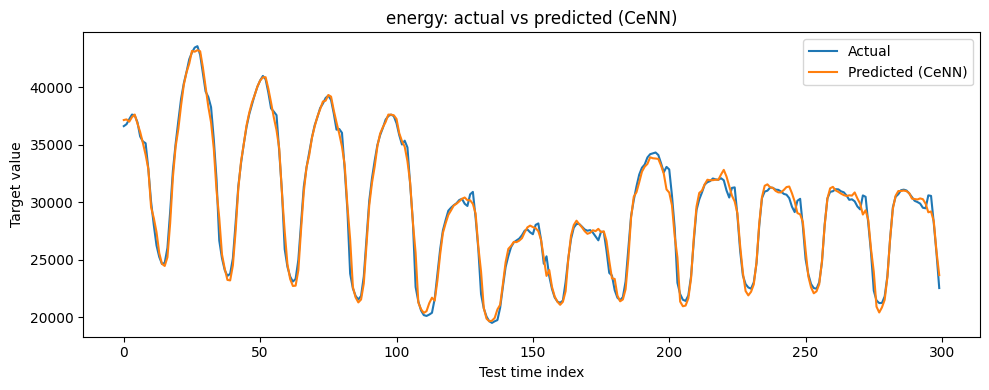

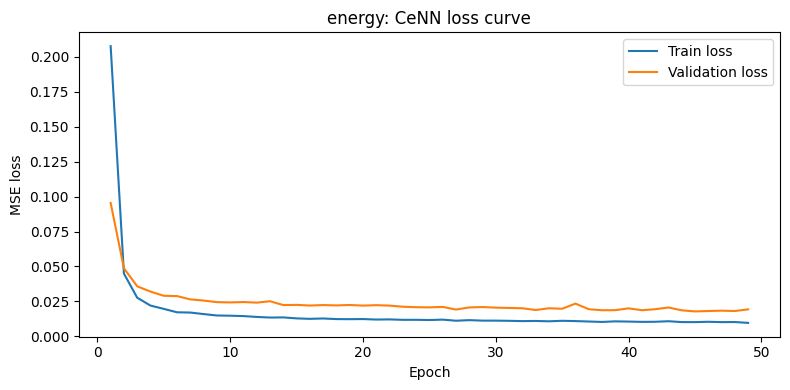

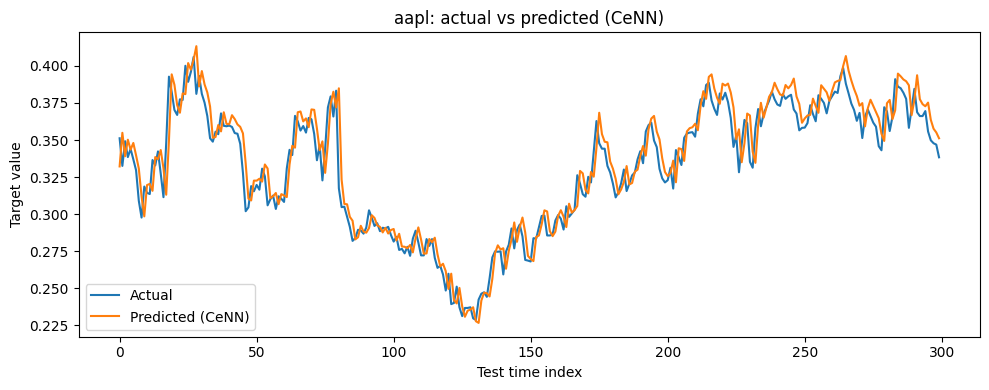

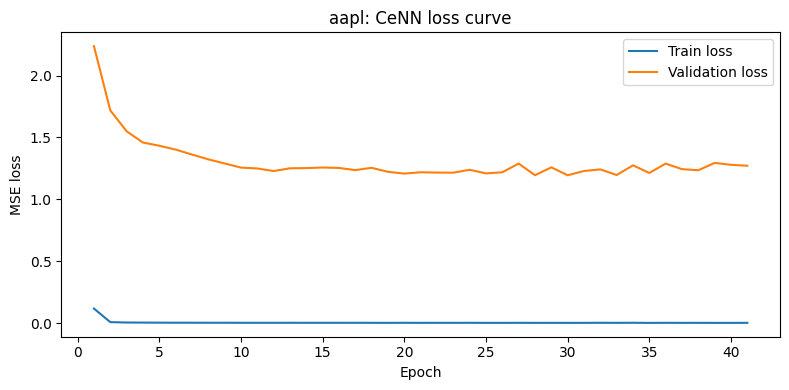

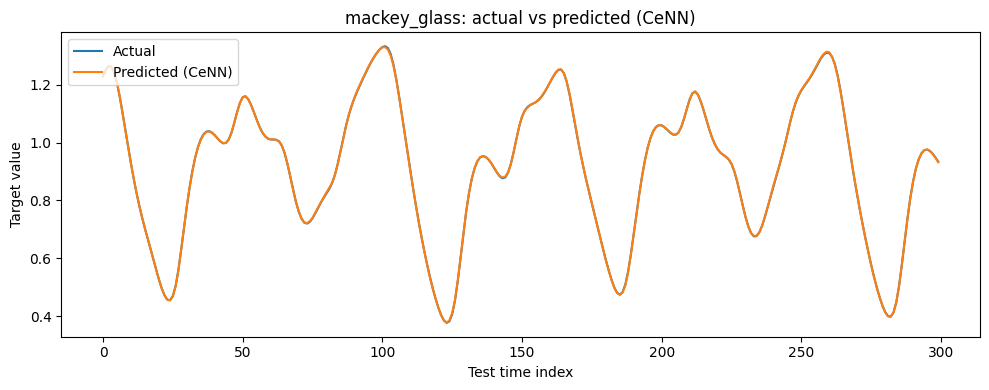

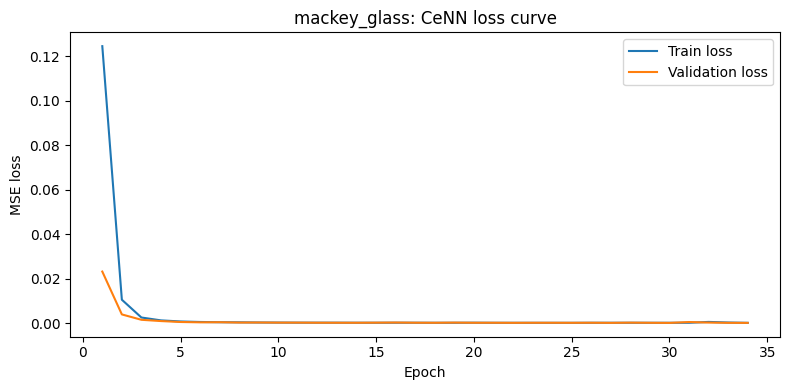

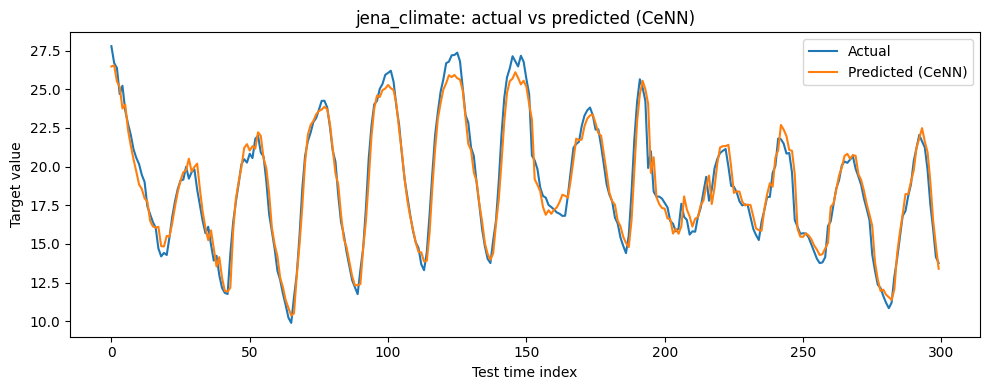

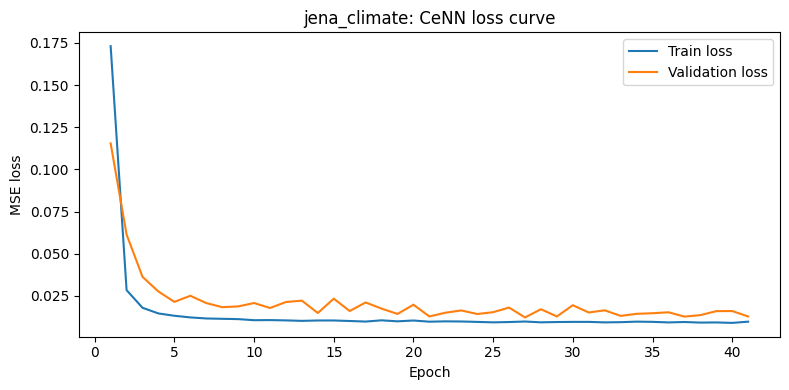

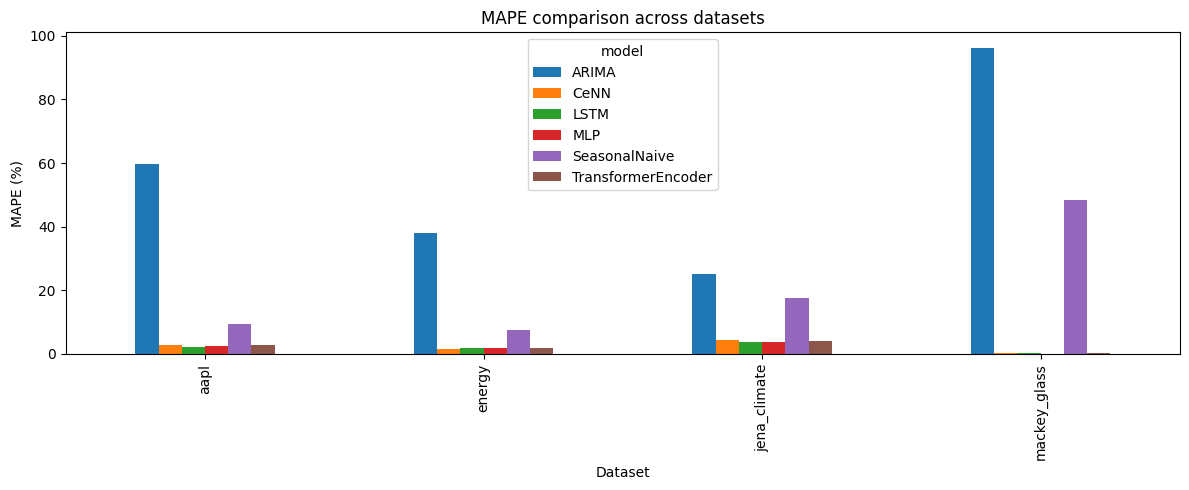

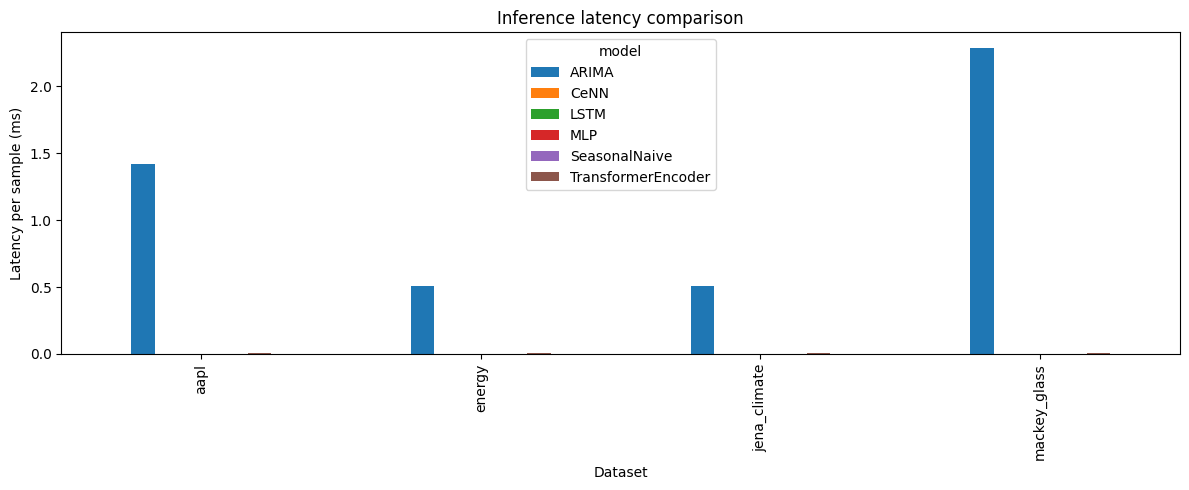

[PosixPath('/kaggle/working/outputs_revision/figures/training_loss_energy_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/training_loss_mackey_glass_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/actual_vs_predicted_jena_climate_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/actual_vs_predicted_energy_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/training_loss_aapl_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/actual_vs_predicted_aapl_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/mape_comparison_all_datasets.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/training_loss_jena_climate_CeNN.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/latency_comparison_all_datasets.png'),
 PosixPath('/kaggle/working/outputs_revision/figures/actual_vs_predicted_mackey_glass_CeNN.png')]

In [15]:
def aggregate_predictions_for_model_local(dataset, model="CeNN"):
    return aggregate_predictions_for_model(pred_df, dataset, model)

def save_actual_vs_pred(dataset, model="CeNN", max_points=300):
    agg = aggregate_predictions_for_model_local(dataset, model)
    if agg is None:
        return
    sub = agg.iloc[:max_points]
    plt.figure(figsize=(10, 4))
    plt.plot(sub["t_index"], sub["y_true"], label="Actual")
    plt.plot(sub["t_index"], sub["y_pred"], label=f"Predicted ({model})")
    plt.title(f"{dataset}: actual vs predicted ({model})")
    plt.xlabel("Test time index")
    plt.ylabel("Target value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / f"actual_vs_predicted_{dataset}_{model}.png", dpi=200)
    plt.show()

def save_loss_curve(dataset, model="CeNN"):
    df = history_df[(history_df["dataset"] == dataset) & (history_df["model"] == model)]
    if df.empty:
        return
    avg = df.groupby("epoch", as_index=False).agg(train_loss=("train_loss", "mean"), val_loss=("val_loss", "mean"))
    plt.figure(figsize=(8, 4))
    plt.plot(avg["epoch"], avg["train_loss"], label="Train loss")
    plt.plot(avg["epoch"], avg["val_loss"], label="Validation loss")
    plt.title(f"{dataset}: {model} loss curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / f"training_loss_{dataset}_{model}.png", dpi=200)
    plt.show()

def save_mape_barplot():
    pivot = summary_df.pivot(index="dataset", columns="model", values="MAPE_mean")
    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title("MAPE comparison across datasets")
    ax.set_ylabel("MAPE (%)")
    ax.set_xlabel("Dataset")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "mape_comparison_all_datasets.png", dpi=200)
    plt.show()

def save_latency_barplot():
    pivot = summary_df.pivot(index="dataset", columns="model", values="inference_latency_ms_mean")
    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Inference latency comparison")
    ax.set_ylabel("Latency per sample (ms)")
    ax.set_xlabel("Dataset")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "latency_comparison_all_datasets.png", dpi=200)
    plt.show()

for ds in prepared.keys():
    save_actual_vs_pred(ds, "CeNN")
    save_loss_curve(ds, "CeNN")

save_mape_barplot()
save_latency_barplot()
list((OUT_DIR / "figures").glob("*.png"))[:10]

## 12. Protocol and hyperparameter LaTeX tables

In [16]:
protocol_rows = [
    ("Evaluation type", "Reproducibility-oriented proof-of-concept benchmark"),
    ("Datasets", "Energy, AAPL finance, Mackey-Glass, Jena Climate"),
    ("Split", "Strict chronological 70% train / 15% validation / 15% test"),
    ("Window length", str(CONFIG["window"])),
    ("Forecast horizon", str(CONFIG["horizon"])),
    ("Seeds", ", ".join(map(str, CONFIG["seeds"]))),
    ("Scaler", "StandardScaler fitted on training set only"),
    ("Metrics", "MAE, RMSE, MAPE, sMAPE, R2, inference latency, training time"),
    ("Statistical validation", "Run-level paired tests, point-level tests, block-bootstrap CI, Diebold-Mariano-style p-value"),
    ("Hardware", f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}"),
    ("Main framework", f"PyTorch {torch.__version__}"),
    ("Dataset roots", "; ".join(CONFIG.get("data_roots", []))),
]
protocol_df = pd.DataFrame(protocol_rows, columns=["Item", "Protocol"])
protocol_df.to_csv(OUT_DIR / "tables" / "table_experimental_protocol.csv", index=False)
with open(OUT_DIR / "tables" / "table_experimental_protocol.tex", "w") as f:
    f.write(protocol_df.to_latex(index=False, escape=False))

hyper_rows = [
    ("Optimizer", "Adam"),
    ("Learning rate", CONFIG["learning_rate"]),
    ("Weight decay", CONFIG["weight_decay"]),
    ("Batch size", CONFIG["batch_size"]),
    ("Max epochs", CONFIG["epochs"]),
    ("Early stopping patience", CONFIG["patience"]),
    ("Gradient clipping", "max_norm=1.0"),
    ("MLP hidden size", CONFIG["mlp_hidden"]),
    ("LSTM hidden size", CONFIG["lstm_hidden"]),
    ("Transformer d_model", CONFIG["transformer_d_model"]),
    ("Transformer heads", CONFIG["transformer_nhead"]),
    ("Transformer layers", CONFIG["transformer_layers"]),
    ("CeNN cells", CONFIG["cenn_cells"]),
    ("CeNN local radius", CONFIG["cenn_radius"]),
    ("CeNN local neighbors per cell", 2 * CONFIG["cenn_radius"] + 1),
    ("CeNN integration steps", CONFIG["cenn_steps"]),
    ("CeNN dt", CONFIG["cenn_dt"]),
    ("CeNN parameterization", "local A/B templates with 1D ring neighborhood"),
]
hyper_df = pd.DataFrame(hyper_rows, columns=["Hyperparameter", "Value"])
hyper_df.to_csv(OUT_DIR / "tables" / "table_hyperparameters.csv", index=False)
with open(OUT_DIR / "tables" / "table_hyperparameters.tex", "w") as f:
    f.write(hyper_df.to_latex(index=False, escape=False))

env_df = pd.DataFrame(list(ENV_INFO.items()), columns=["Component", "Version / value"])
env_df.to_csv(OUT_DIR / "tables" / "table_environment.csv", index=False)
with open(OUT_DIR / "tables" / "table_environment.tex", "w") as f:
    f.write(env_df.to_latex(index=False, escape=False))

display(protocol_df)
display(hyper_df)
display(env_df)


,Item,Protocol
0,Evaluation type,Reproducibility-oriented proof-of-concept benc...
1,Datasets,"Energy, AAPL finance, Mackey-Glass, Jena Climate"
2,Split,Strict chronological 70% train / 15% validatio...
3,Window length,24
4,Forecast horizon,1
5,Seeds,"42, 43, 44, 45, 46"
6,Scaler,StandardScaler fitted on training set only
7,Metrics,"MAE, RMSE, MAPE, sMAPE, R2, inference latency,..."
8,Statistical validation,"Run-level paired tests, point-level tests, blo..."
9,Hardware,Tesla T4


,Hyperparameter,Value
0,Optimizer,Adam
1,Learning rate,0.001
2,Weight decay,0.00001
3,Batch size,64
4,Max epochs,50
5,Early stopping patience,8
6,Gradient clipping,max_norm=1.0
7,MLP hidden size,128
8,LSTM hidden size,64
9,Transformer d_model,64


,Component,Version / value
0,python,3.12.12
1,platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,torch,2.10.0+cu128
3,cuda_available,True
4,cuda_device,Tesla T4
5,numpy,2.0.2
6,pandas,2.3.3


## 13. Final audit and ZIP package

In [17]:
audit = {
    "any_synthetic_fallback": bool(dataset_metadata["is_synthetic_fallback"].any()),
    "fallback_datasets": dataset_metadata.loc[dataset_metadata["is_synthetic_fallback"], "dataset"].tolist(),
    "n_datasets": len(dataset_metadata),
    "models_in_main_results": sorted(metrics_df["model"].unique().tolist()),
    "n_metric_rows": int(len(metrics_df)),
    "n_prediction_rows": int(len(pred_df)),
    "config_path": str(OUT_DIR / "configs" / "experiment_config.json"),
    "results_dir": str(OUT_DIR / "results"),
    "tables_dir": str(OUT_DIR / "tables"),
    "figures_dir": str(OUT_DIR / "figures"),
}
with open(OUT_DIR / "logs" / "final_audit.json", "w") as f:
    json.dump(audit, f, indent=2)

zip_path = Path("/kaggle/working/outputs_revision_package.zip")
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for file in OUT_DIR.rglob("*"):
        if file.is_file():
            z.write(file, arcname=file.relative_to(OUT_DIR.parent))

print("Audit:", audit)
print("Created:", zip_path)
print("Size MB:", zip_path.stat().st_size / (1024**2))

Audit: {'any_synthetic_fallback': False, 'fallback_datasets': [], 'n_datasets': 4, 'models_in_main_results': ['ARIMA', 'CeNN', 'LSTM', 'MLP', 'SeasonalNaive', 'TransformerEncoder'], 'n_metric_rows': 88, 'n_prediction_rows': 77088, 'config_path': '/kaggle/working/outputs_revision/configs/experiment_config.json', 'results_dir': '/kaggle/working/outputs_revision/results', 'tables_dir': '/kaggle/working/outputs_revision/tables', 'figures_dir': '/kaggle/working/outputs_revision/figures'}
Created: /kaggle/working/outputs_revision_package.zip
Size MB: 2.379800796508789


## 14. Manuscript integration checklist

Use:
- `outputs_revision/tables/table_main_results.tex`
- `outputs_revision/tables/table_statistical_validation.tex`
- `outputs_revision/tables/table_experimental_protocol.tex`
- `outputs_revision/tables/table_hyperparameters.tex`
- `outputs_revision/tables/table_ablation.tex`
- `outputs_revision/figures/*.png`
- `outputs_revision/results/*.csv`

Do not use the results if `any_synthetic_fallback=True`.